# Homework 4

This notebook uses SVM classification for the cancer dataset and SVR regression for the US Housing dataset. Both problems use an 80/20 training and testing split.

In [1]:
# Import the libraries used for the data, graphs, and calculations.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Connect Google Drive so I can load both datasets.
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Problem 1: Cancer Classification with SVM

I tested linear, polynomial, RBF, and sigmoid kernels. I then compared the best SVM with logistic regression and my Homework 3 result.

In [2]:
# Load the cancer dataset and preview the first five rows.
file_path = '/content/drive/MyDrive/Dataset/Cancer.csv'
cancer = pd.read_csv(file_path)
print('Dataset shape:', cancer.shape)
cancer.head()

Dataset shape: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [3]:
# Optional checks for column names, class counts, and missing values.
# print(cancer.columns)
# print('Diagnosis counts:')
# print(cancer['diagnosis'].value_counts())
# print('Missing values:')
# print(cancer.isnull().sum())

In [4]:
# Remove columns that are not model inputs and encode the diagnosis.
X_cancer = cancer.drop(columns=['id', 'diagnosis', 'Unnamed: 32'])
Y_cancer = cancer['diagnosis'].map({'B': 0, 'M': 1})

print('Input shape:', X_cancer.shape)
print('Target shape:', Y_cancer.shape)
print(Y_cancer.value_counts())

Input shape: (569, 30)
Target shape: (569,)
diagnosis
0    357
1    212
Name: count, dtype: int64


In [5]:
# Split the cancer data into 80% training and 20% testing data.
from sklearn.model_selection import train_test_split

X_cancer_train, X_cancer_test, Y_cancer_train, Y_cancer_test = train_test_split(
    X_cancer, Y_cancer, test_size=0.20, random_state=42, stratify=Y_cancer)

print('Training input:', X_cancer_train.shape)
print('Testing input:', X_cancer_test.shape)
print('Training target:', Y_cancer_train.shape)
print('Testing target:', Y_cancer_test.shape)

Training input: (455, 30)
Testing input: (114, 30)
Training target: (455,)
Testing target: (114,)


In [6]:
# Standardize the cancer inputs using the training data only.
from sklearn.preprocessing import StandardScaler

cancer_scaler = StandardScaler()
X_cancer_train_scaled = cancer_scaler.fit_transform(X_cancer_train)
X_cancer_test_scaled = cancer_scaler.transform(X_cancer_test)

In [7]:
# Train one SVM for each kernel and save every evaluation score.
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

kernels = ['linear', 'poly', 'rbf', 'sigmoid']
svm_results = []
svm_models = {}

for kernel in kernels:
    svm_model = SVC(kernel=kernel)
    svm_model.fit(X_cancer_train_scaled, Y_cancer_train)
    Y_cancer_pred = svm_model.predict(X_cancer_test_scaled)

    accuracy = accuracy_score(Y_cancer_test, Y_cancer_pred)
    precision = precision_score(Y_cancer_test, Y_cancer_pred, zero_division=0)
    recall = recall_score(Y_cancer_test, Y_cancer_pred, zero_division=0)
    f1 = f1_score(Y_cancer_test, Y_cancer_pred, zero_division=0)

    svm_models[kernel] = svm_model
    svm_results.append({'Kernel': kernel, 'Accuracy': accuracy, 'Precision': precision,
                        'Recall': recall, 'F1 Score': f1})

In [8]:
# Put the SVM results into one table.
svm_results_df = pd.DataFrame(svm_results)
svm_results_df

,Kernel,Accuracy,Precision,Recall,F1 Score
0,linear,0.964912,1.000000,0.904762,0.950000
1,poly,0.885965,1.000000,0.690476,0.816901
2,rbf,0.973684,1.000000,0.928571,0.962963
3,sigmoid,0.947368,0.973684,0.880952,0.925000


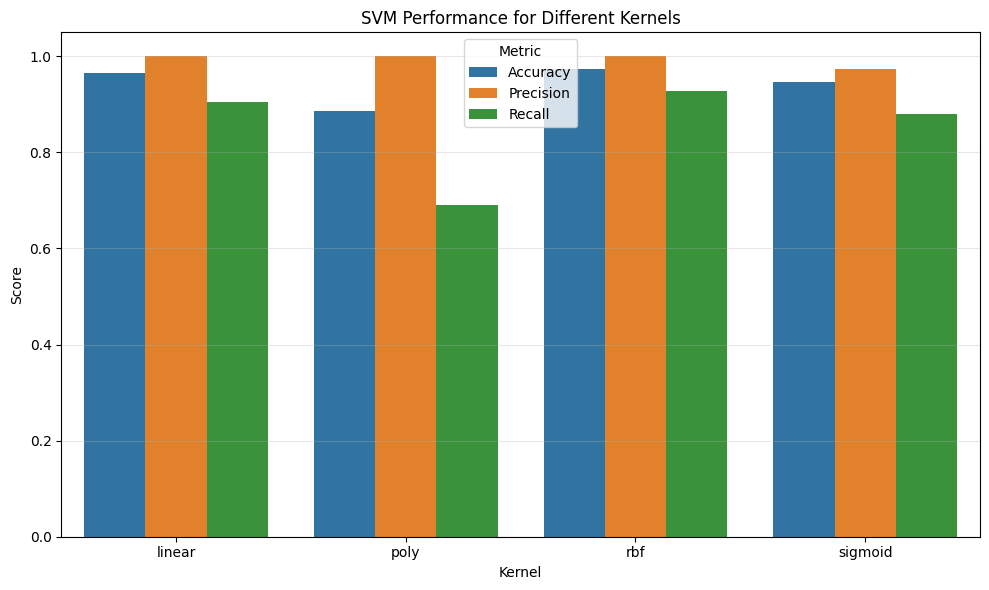

In [9]:
# Plot accuracy, precision, and recall for every SVM kernel.
plot_results = svm_results_df.melt(id_vars='Kernel', value_vars=['Accuracy', 'Precision', 'Recall'],
                                   var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_results, x='Kernel', y='Score', hue='Metric')
plt.title('SVM Performance for Different Kernels')
plt.xlabel('Kernel')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.legend(title='Metric')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

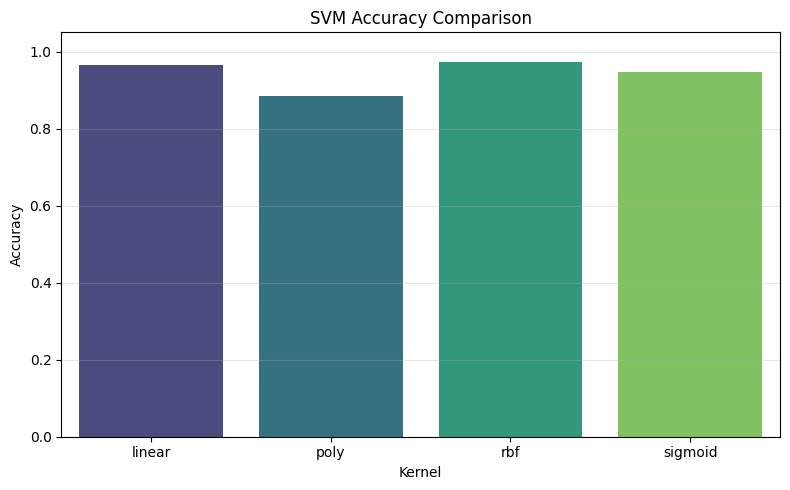

In [10]:
# Compare only the classification accuracy of the kernels.
plt.figure(figsize=(8, 5))
sns.barplot(data=svm_results_df, x='Kernel', y='Accuracy', hue='Kernel',
            palette='viridis', legend=False)
plt.title('SVM Accuracy Comparison')
plt.xlabel('Kernel')
plt.ylabel('Accuracy')
plt.ylim(0, 1.05)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
# Select the kernel with the highest test accuracy.
best_row = svm_results_df.loc[svm_results_df['Accuracy'].idxmax()]
best_kernel = best_row['Kernel']

print('Best kernel:', best_kernel)
print(best_row)

Best kernel: rbf
Kernel            rbf
Accuracy     0.973684
Precision         1.0
Recall       0.928571
F1 Score     0.962963
Name: 2, dtype: object


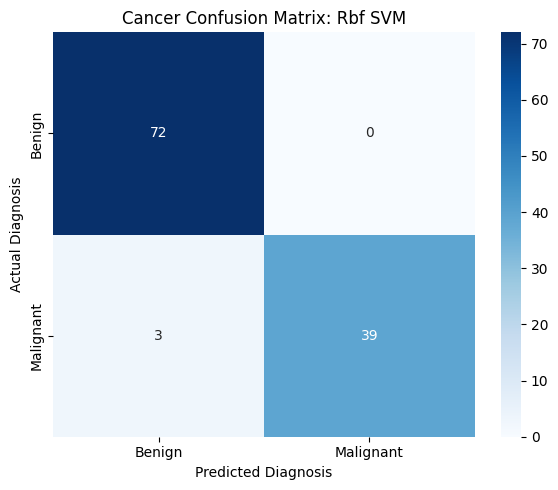

              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



In [12]:
# Plot the confusion matrix and print the report for the best SVM.
from sklearn.metrics import confusion_matrix, classification_report

best_svm_model = svm_models[best_kernel]
Y_cancer_best_pred = best_svm_model.predict(X_cancer_test_scaled)
best_svm_cm = confusion_matrix(Y_cancer_test, Y_cancer_best_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(best_svm_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.title(f'Cancer Confusion Matrix: {best_kernel.capitalize()} SVM')
plt.xlabel('Predicted Diagnosis')
plt.ylabel('Actual Diagnosis')
plt.tight_layout()
plt.show()

print(classification_report(Y_cancer_test, Y_cancer_best_pred,
                            target_names=['Benign', 'Malignant']))

In [13]:
# Train a logistic regression baseline using the same split and scaled inputs.
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(max_iter=1000, random_state=42)
logistic_model.fit(X_cancer_train_scaled, Y_cancer_train)
Y_logistic_pred = logistic_model.predict(X_cancer_test_scaled)

logistic_accuracy = accuracy_score(Y_cancer_test, Y_logistic_pred)
logistic_precision = precision_score(Y_cancer_test, Y_logistic_pred)
logistic_recall = recall_score(Y_cancer_test, Y_logistic_pred)
logistic_f1 = f1_score(Y_cancer_test, Y_logistic_pred)

print(f'Accuracy:  {logistic_accuracy:.4f}')
print(f'Precision: {logistic_precision:.4f}')
print(f'Recall:    {logistic_recall:.4f}')
print(f'F1 Score:  {logistic_f1:.4f}')

Accuracy:  0.9649
Precision: 0.9750
Recall:    0.9286
F1 Score:  0.9512


In [14]:
# Compare the best SVM with the new logistic regression baseline.
comparison = pd.DataFrame({'Model': ['Logistic Regression', f'{best_kernel.capitalize()} SVM'],
                           'Accuracy': [logistic_accuracy, best_row['Accuracy']], 'Precision': [logistic_precision, best_row['Precision']], 'Recall': [logistic_recall, best_row['Recall']], 'F1 Score': [logistic_f1, best_row['F1 Score']]})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.964912,0.975,0.928571,0.951220
1,Rbf SVM,0.973684,1.000,0.928571,0.962963


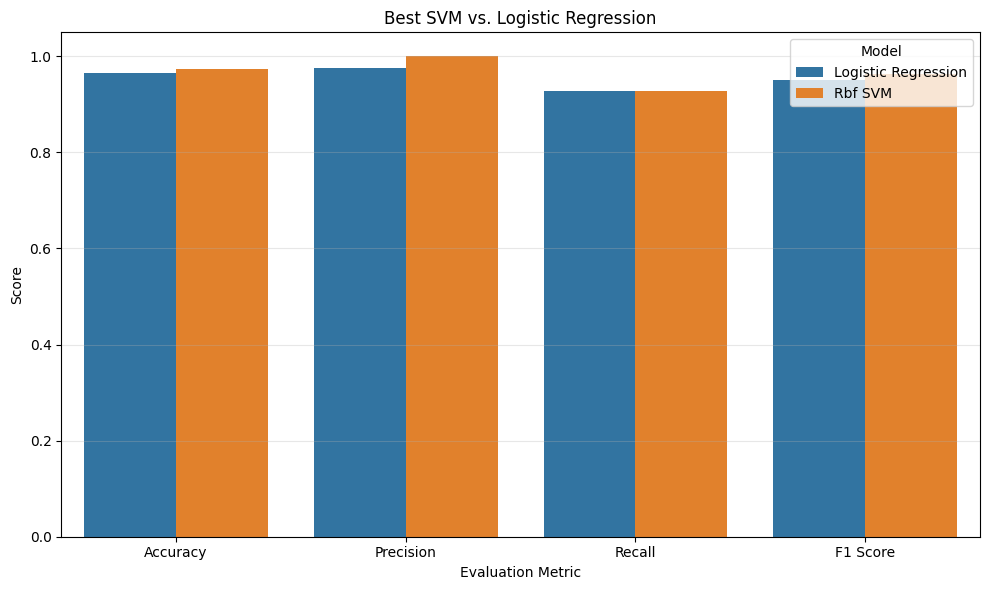

In [15]:
# Plot the best SVM beside the logistic regression baseline.
comparison_plot = comparison.melt(id_vars='Model', value_vars=['Accuracy', 'Precision', 'Recall', 'F1 Score'],
                                  var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
sns.barplot(data=comparison_plot, x='Metric', y='Score', hue='Model')
plt.title('Best SVM vs. Logistic Regression')
plt.xlabel('Evaluation Metric')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
# Enter my Homework 3 L2 logistic regression scores for a direct comparison.
hw3_comparison = pd.DataFrame({'Model': ['HW3 L2 Logistic Regression', 'HW4 RBF SVM'],
                               'Accuracy': [0.982456, best_row['Accuracy']], 'Precision': [1.000000, best_row['Precision']], 'Recall': [0.952381, best_row['Recall']], 'F1 Score': [0.975610, best_row['F1 Score']]})

hw3_comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,HW3 L2 Logistic Regression,0.982456,1.0,0.952381,0.975610
1,HW4 RBF SVM,0.973684,1.0,0.928571,0.962963


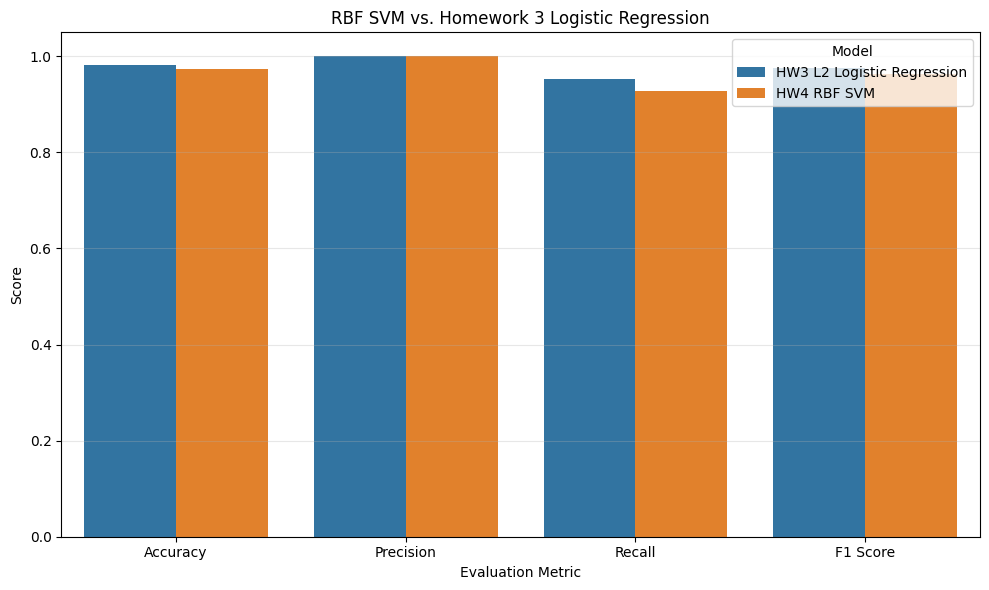

In [17]:
# Plot the Homework 4 RBF SVM beside my Homework 3 result.
hw3_plot = hw3_comparison.melt(id_vars='Model', value_vars=['Accuracy', 'Precision', 'Recall', 'F1 Score'],
                               var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
sns.barplot(data=hw3_plot, x='Metric', y='Score', hue='Model')
plt.title('RBF SVM vs. Homework 3 Logistic Regression')
plt.xlabel('Evaluation Metric')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Problem 2: Housing Price Prediction with SVR

I used the 11 required housing inputs, tested three SVR kernels, and compared the best SVR with Ridge regression from Homework 1.

In [18]:
# Load the housing dataset and preview the first five rows.
file_path = '/content/drive/MyDrive/Dataset/Housing.csv'
housing = pd.read_csv(file_path)
print('Dataset shape:', housing.shape)
housing.head()

Dataset shape: (545, 13)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [19]:
# Select the 11 required inputs and the housing price target.
housing_features = ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
                    'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea']

X_housing = housing[housing_features].copy()
Y_housing = housing['price'].copy()

print('Input shape:', X_housing.shape)
print('Target shape:', Y_housing.shape)
X_housing.head()

Input shape: (545, 11)
Target shape: (545,)


,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea
0,7420,4,2,3,yes,no,no,no,yes,2,yes
1,8960,4,4,4,yes,no,no,no,yes,3,no
2,9960,3,2,2,yes,no,yes,no,no,2,yes
3,7500,4,2,2,yes,no,yes,no,yes,3,yes
4,7420,4,1,2,yes,yes,yes,no,yes,2,no


In [20]:
# Change every yes/no housing column to 1/0.
categorical_columns = ['mainroad', 'guestroom', 'basement', 'hotwaterheating',
                       'airconditioning', 'prefarea']

for column in categorical_columns:
    X_housing[column] = X_housing[column].map({'yes': 1, 'no': 0})

X_housing.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea
0,7420,4,2,3,1,0,0,0,1,2,1
1,8960,4,4,4,1,0,0,0,1,3,0
2,9960,3,2,2,1,0,1,0,0,2,1
3,7500,4,2,2,1,0,1,0,1,3,1
4,7420,4,1,2,1,1,1,0,1,2,0


In [21]:
# Split the housing data into 80% training and 20% testing data.
from sklearn.model_selection import train_test_split

X_house_train, X_house_test, Y_house_train, Y_house_test = train_test_split(
    X_housing, Y_housing, test_size=0.20, random_state=42)

print('Training input:', X_house_train.shape)
print('Testing input:', X_house_test.shape)
print('Training target:', Y_house_train.shape)
print('Testing target:', Y_house_test.shape)

Training input: (436, 11)
Testing input: (109, 11)
Training target: (436,)
Testing target: (109,)


In [22]:
# Optional checks for data types and missing values after encoding.
# print(X_housing.dtypes)
# print('Missing values after encoding:')
# print(X_housing.isnull().sum())

In [23]:
# Standardize the housing inputs and price target using training data only.
from sklearn.preprocessing import StandardScaler

X_house_scaler = StandardScaler()
Y_house_scaler = StandardScaler()
X_house_train_scaled = X_house_scaler.fit_transform(X_house_train)
X_house_test_scaled = X_house_scaler.transform(X_house_test)
Y_house_train_scaled = Y_house_scaler.fit_transform(
    Y_house_train.values.reshape(-1, 1)).ravel()
Y_house_test_scaled = Y_house_scaler.transform(
    Y_house_test.values.reshape(-1, 1)).ravel()

print('Scaled training input:', X_house_train_scaled.shape)
print('Scaled testing input:', X_house_test_scaled.shape)
print('Scaled training target:', Y_house_train_scaled.shape)
print('Scaled testing target:', Y_house_test_scaled.shape)

Scaled training input: (436, 11)
Scaled testing input: (109, 11)
Scaled training target: (436,)
Scaled testing target: (109,)


In [24]:
# Train three SVR kernels and convert predictions back to dollar values.
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

svr_models = {'RBF': SVR(kernel='rbf', C=1000, gamma=0.1), 'Linear': SVR(kernel='linear', C=1000),
              'Polynomial': SVR(kernel='poly', C=1000, degree=2)}
svr_results = []
svr_predictions = {}

for name, model in svr_models.items():
    model.fit(X_house_train_scaled, Y_house_train_scaled)
    prediction_scaled = model.predict(X_house_test_scaled)
    prediction = Y_house_scaler.inverse_transform(prediction_scaled.reshape(-1, 1)).ravel()

    r2 = r2_score(Y_house_test, prediction)
    mae = mean_absolute_error(Y_house_test, prediction)
    rmse = np.sqrt(mean_squared_error(Y_house_test, prediction))

    svr_predictions[name] = prediction
    svr_results.append({'Kernel': name, 'R2 Score': r2, 'MAE': mae, 'RMSE': rmse})

In [25]:
# Put the SVR evaluation results into one table.
svr_results_df = pd.DataFrame(svr_results)
print(svr_results_df)

       Kernel  R2 Score           MAE          RMSE
0         RBF  0.065676  1.338635e+06  2.173156e+06
1      Linear  0.617785  1.000614e+06  1.389939e+06
2  Polynomial  0.506950  1.148805e+06  1.578656e+06


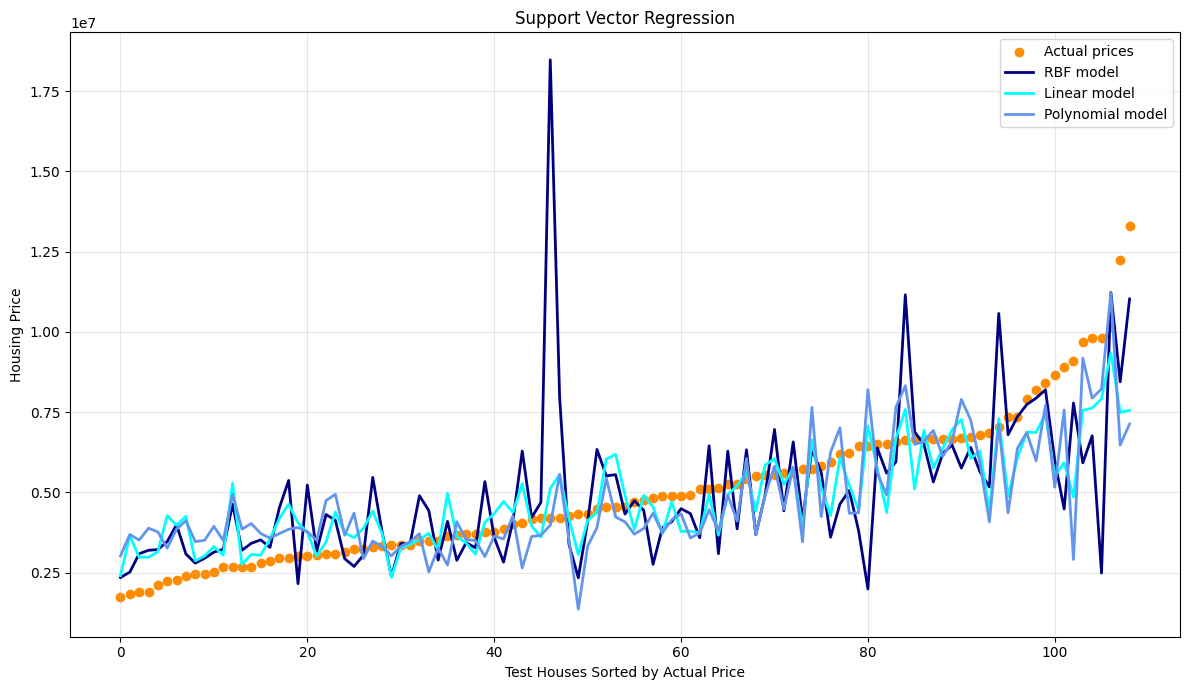

In [26]:
# Sort the test houses and plot actual prices with all SVR predictions.
sort_index = np.argsort(Y_house_test.values)
actual_sorted = Y_house_test.values[sort_index]
sample_numbers = np.arange(len(actual_sorted))
rbf_sorted = svr_predictions['RBF'][sort_index]
linear_sorted = svr_predictions['Linear'][sort_index]
poly_sorted = svr_predictions['Polynomial'][sort_index]

plt.figure(figsize=(12, 7))
plt.scatter(sample_numbers, actual_sorted, color='darkorange', label='Actual prices')
plt.plot(sample_numbers, rbf_sorted, color='navy', linewidth=2, label='RBF model')
plt.plot(sample_numbers, linear_sorted, color='cyan', linewidth=2, label='Linear model')
plt.plot(sample_numbers, poly_sorted, color='cornflowerblue', linewidth=2,
         label='Polynomial model')
plt.xlabel('Test Houses Sorted by Actual Price')
plt.ylabel('Housing Price')
plt.title('Support Vector Regression')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

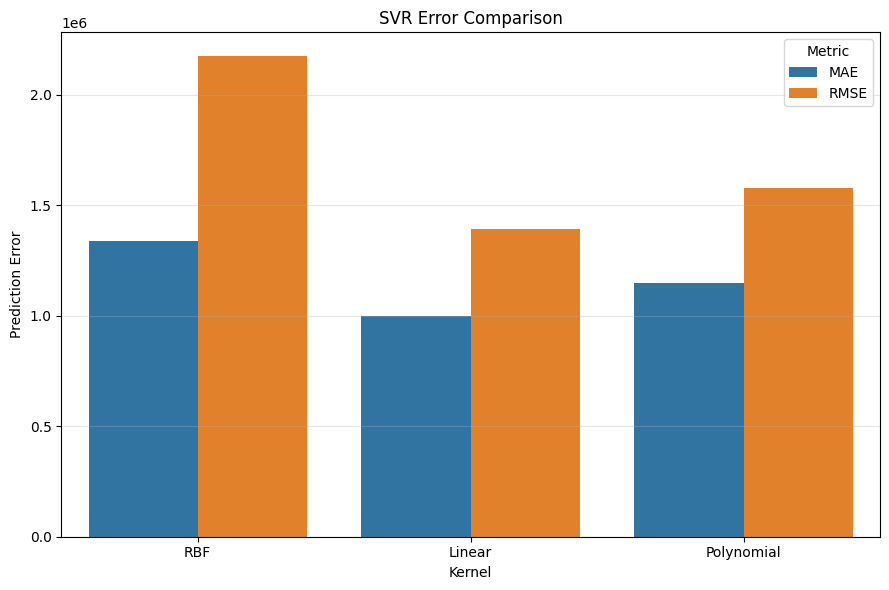

In [27]:
# Compare MAE and RMSE for the three SVR kernels.
svr_errors = svr_results_df.melt(id_vars='Kernel', value_vars=['MAE', 'RMSE'],
                                 var_name='Metric', value_name='Error')

plt.figure(figsize=(9, 6))
sns.barplot(data=svr_errors, x='Kernel', y='Error', hue='Metric')
plt.title('SVR Error Comparison')
plt.xlabel('Kernel')
plt.ylabel('Prediction Error')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [28]:
# Select the SVR kernel with the highest R-squared score.
best_svr_row = svr_results_df.loc[svr_results_df['R2 Score'].idxmax()]
best_svr_kernel = best_svr_row['Kernel']

print('Best SVR kernel:', best_svr_kernel)
print(best_svr_row)

Best SVR kernel: Linear
Kernel              Linear
R2 Score          0.617785
MAE         1000613.938173
RMSE        1389939.295504
Name: 1, dtype: object


In [29]:
# Train Ridge regression for the Homework 1 comparison.
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_house_train_scaled, Y_house_train)
Y_ridge_pred = ridge_model.predict(X_house_test_scaled)

ridge_r2 = r2_score(Y_house_test, Y_ridge_pred)
ridge_mae = mean_absolute_error(Y_house_test, Y_ridge_pred)
ridge_rmse = np.sqrt(mean_squared_error(Y_house_test, Y_ridge_pred))

print(f'R² Score: {ridge_r2:.4f}')
print(f'MAE:      ${ridge_mae:,.2f}')
print(f'RMSE:     ${ridge_rmse:,.2f}')

R² Score: 0.6436
MAE:      $979,146.94
RMSE:     $1,342,156.00


In [30]:
# Put the best SVR and Ridge regression results in one table.
regression_comparison = pd.DataFrame({'Model': ['Ridge Regression', f'{best_svr_kernel} SVR'],
                                      'R2 Score': [ridge_r2, best_svr_row['R2 Score']], 'MAE': [ridge_mae, best_svr_row['MAE']], 'RMSE': [ridge_rmse, best_svr_row['RMSE']]})

print(regression_comparison)

              Model  R2 Score           MAE          RMSE
0  Ridge Regression  0.643613  9.791469e+05  1.342156e+06
1        Linear SVR  0.617785  1.000614e+06  1.389939e+06


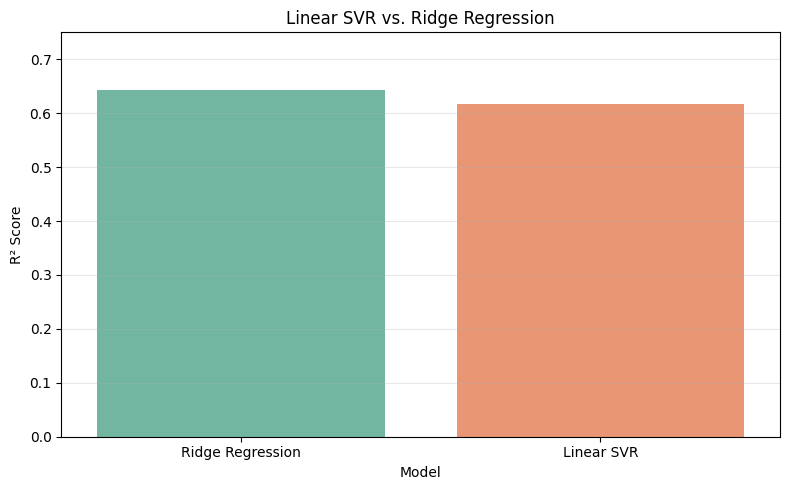

In [31]:
# Compare the R-squared scores of Linear SVR and Ridge regression.
plt.figure(figsize=(8, 5))
sns.barplot(data=regression_comparison, x='Model', y='R2 Score', hue='Model',
            palette='Set2', legend=False)
plt.title('Linear SVR vs. Ridge Regression')
plt.xlabel('Model')
plt.ylabel('R² Score')
plt.ylim(0, 0.75)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

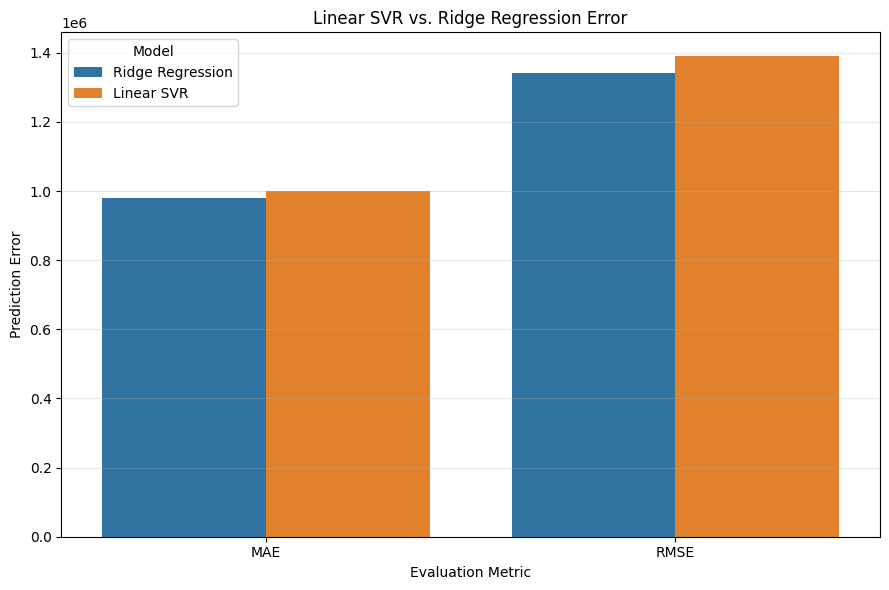

In [32]:
# Compare the MAE and RMSE of Linear SVR and Ridge regression.
regression_errors = regression_comparison.melt(id_vars='Model', value_vars=['MAE', 'RMSE'],
                                                var_name='Metric', value_name='Error')

plt.figure(figsize=(9, 6))
sns.barplot(data=regression_errors, x='Metric', y='Error', hue='Model')
plt.title('Linear SVR vs. Ridge Regression Error')
plt.xlabel('Evaluation Metric')
plt.ylabel('Prediction Error')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Conclusion

The RBF kernel was the best SVM classifier for the cancer data. Linear SVR was the best SVR kernel for housing prices, but Ridge regression produced a slightly higher R-squared score and lower prediction errors.